In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import math
import pickle

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# from fix_data_leakage import scale_data_without_leakage, create_sequences
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [3]:
df = pd.read_csv("E:\Document\PROJECT\data\processed\data2225_done.csv")
df.head()

,Local Time,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,HolidayName,IsHoliday,Accumulated Hours of Rain
0,2022-01-13 07:00:00,353.1,10.0,84.0,98.0,17.08,52.0,100,0.00,1020.0,95.0,15.5,0.6,2.00,Ngày thường,False,0
1,2022-01-13 08:00:00,343.5,9.0,87.3,95.7,16.75,48.7,91,0.00,1021.0,94.0,15.4,0.7,2.33,Ngày thường,False,0
2,2022-01-13 09:00:00,334.0,8.0,90.7,93.3,16.42,45.3,83,0.50,1022.0,93.0,15.3,1.0,2.66,Ngày thường,False,1
3,2022-01-13 10:00:00,324.5,7.0,94.0,91.0,16.09,42.0,75,0.75,1022.0,93.0,15.2,1.5,3.00,Ngày thường,False,2
4,2022-01-13 11:00:00,319.6,6.7,95.7,91.3,16.17,39.0,83,0.00,1021.0,87.0,15.6,1.9,3.00,Ngày thường,False,0


In [4]:

df['Local Time'] = pd.to_datetime(df['Local Time'])
df = df.set_index('Local Time').sort_index()

In [5]:
df = df.drop(columns=['HolidayName'])
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34759 entries, 2022-01-13 07:00:00 to 2025-12-31 23:00:00
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CO                         34759 non-null  float64
 1   NO2                        34759 non-null  float64
 2   O3                         34759 non-null  float64
 3   PM10                       34759 non-null  float64
 4   PM25                       34759 non-null  float64
 5   SO2                        34759 non-null  float64
 6   Clouds                     34759 non-null  int64  
 7   Precipitation              34759 non-null  float64
 8   Pressure                   34759 non-null  float64
 9   Relative Humidity          34759 non-null  float64
 10  Temperature                34759 non-null  float64
 11  UV Index                   34759 non-null  float64
 12  Wind Speed                 34759 non-null  float64
 13  IsHoliday  

In [6]:
# ===== Time features =====
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek   # Monday=0, Sunday=6
df["month"] = df.index.month

# ===== PM25 lag features =====
df["PM25_lag_1"] = df["PM25"].shift(1)
df["PM25_lag_3"] = df["PM25"].shift(3)
df["PM25_lag_24"] = df["PM25"].shift(24)

# ===== Rolling mean của PM25 quá khứ =====
# shift(1) để không ăn vào giá trị hiện tại
df["PM25_roll_mean_3"] = df["PM25"].shift(1).rolling(window=3).mean()
df["PM25_roll_mean_6"] = df["PM25"].shift(1).rolling(window=6).mean()
df["PM25_roll_mean_24"] = df["PM25"].shift(1).rolling(window=24).mean()

# nếu muốn thêm rolling std
df["PM25_roll_std_24"] = df["PM25"].shift(1).rolling(window=24).std()

# bỏ các dòng đầu bị NaN do lag/rolling
df = df.dropna().copy()

print(df[[
    "PM25", "PM25_lag_1", "PM25_lag_3", "PM25_lag_24",
    "PM25_roll_mean_3", "PM25_roll_mean_6", "PM25_roll_mean_24",
    "hour", "dayofweek", "month"
]].head())

                      PM25  PM25_lag_1  PM25_lag_3  PM25_lag_24  \
Local Time                                                        
2022-01-14 07:00:00  24.75       27.31       32.42        17.08   
2022-01-14 08:00:00  22.36       24.75       29.87        16.75   
2022-01-14 09:00:00  19.97       22.36       27.31        16.42   
2022-01-14 10:00:00  17.57       19.97       24.75        16.09   
2022-01-14 11:00:00  16.01       17.57       22.36        16.17   

                     PM25_roll_mean_3  PM25_roll_mean_6  PM25_roll_mean_24  \
Local Time                                                                   
2022-01-14 07:00:00         29.866667         31.063333          22.317500   
2022-01-14 08:00:00         27.310000         29.825000          22.637083   
2022-01-14 09:00:00         24.806667         28.175000          22.870833   
2022-01-14 10:00:00         22.360000         26.113333          23.018750   
2022-01-14 11:00:00         19.966667         23.638333       

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns

skew_df = pd.DataFrame({
    "skew": df[num_cols].skew(numeric_only=True),
    "mean": df[num_cols].mean(numeric_only=True),
    "median": df[num_cols].median(numeric_only=True),
    "min": df[num_cols].min(numeric_only=True),
    "max": df[num_cols].max(numeric_only=True)
}).sort_values("skew", ascending=False)

print(skew_df)

                               skew         mean       median         min  \
Precipitation              6.051879     0.303443     0.000000    0.000000   
Accumulated Hours of Rain  5.659202     1.286397     0.000000    0.000000   
PM10                       4.800138    42.719433    30.330000    1.200000   
SO2                        4.112703    36.243248    29.820000    0.420000   
CO                         3.258514   516.049486   195.500000   10.000000   
NO2                        3.157886    18.150369    11.040000    1.000000   
PM25_lag_24                2.397467    21.040636    16.500000    0.960000   
PM25_lag_3                 2.393342    21.063103    16.500000    0.960000   
PM25_lag_1                 2.393099    21.063705    16.500000    0.960000   
PM25                       2.392945    21.064105    16.500000    0.960000   
PM25_roll_mean_3           2.283240    21.063416    16.746667    0.960000   
PM25_roll_mean_6           2.183575    21.062778    16.883333    0.960000   

In [8]:
skew_df["abs_skew"] = skew_df["skew"].abs()

strong_skew = skew_df[skew_df["abs_skew"] >= 1].sort_values("abs_skew", ascending=False)
moderate_skew = skew_df[(skew_df["abs_skew"] >= 0.5) & (skew_df["abs_skew"] < 1)]

print("=== Cột lệch mạnh ===")
print(strong_skew[["skew", "mean", "median", "min", "max"]])

print("\n=== Cột lệch vừa ===")
print(moderate_skew[["skew", "mean", "median", "min", "max"]])

=== Cột lệch mạnh ===
                               skew        mean      median        min  \
Precipitation              6.051879    0.303443    0.000000   0.000000   
Accumulated Hours of Rain  5.659202    1.286397    0.000000   0.000000   
PM10                       4.800138   42.719433   30.330000   1.200000   
SO2                        4.112703   36.243248   29.820000   0.420000   
CO                         3.258514  516.049486  195.500000  10.000000   
NO2                        3.157886   18.150369   11.040000   1.000000   
PM25_lag_24                2.397467   21.040636   16.500000   0.960000   
PM25_lag_3                 2.393342   21.063103   16.500000   0.960000   
PM25_lag_1                 2.393099   21.063705   16.500000   0.960000   
PM25                       2.392945   21.064105   16.500000   0.960000   
PM25_roll_mean_3           2.283240   21.063416   16.746667   0.960000   
PM25_roll_mean_6           2.183575   21.062778   16.883333   0.960000   
PM25_roll_std_24

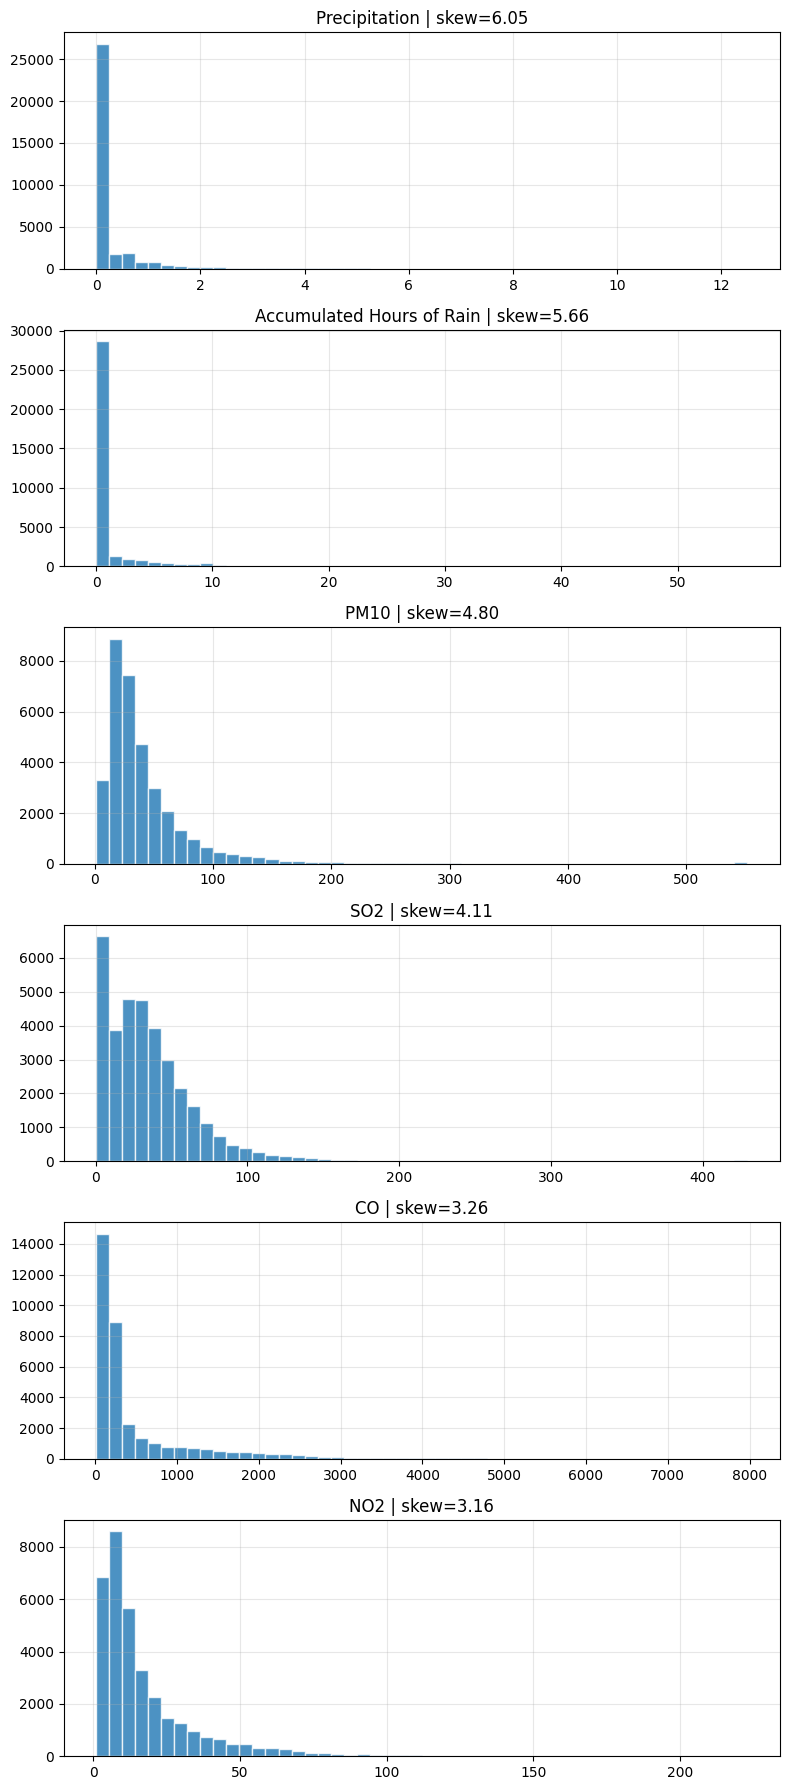

In [9]:
cols_to_plot = strong_skew.index.tolist()[:6]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(8, 3*len(cols_to_plot)))
if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df[col].dropna(), bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(f"{col} | skew={df[col].skew():.2f}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
(df["PM25"] < 0).sum(), df.loc[df["PM25"] < 0, "PM25"].describe()

(np.int64(0),
 count    0.0
 mean     NaN
 std      NaN
 min      NaN
 25%      NaN
 50%      NaN
 75%      NaN
 max      NaN
 Name: PM25, dtype: float64)

In [15]:
y_train_raw = train_df["PM25"].to_numpy()
y_val_raw = val_df["PM25"].to_numpy()
y_test_raw = test_df["PM25"].to_numpy()

y_train_t = train_log.to_numpy()
y_val_t = val_log.to_numpy()
y_test_t = test_log.to_numpy()

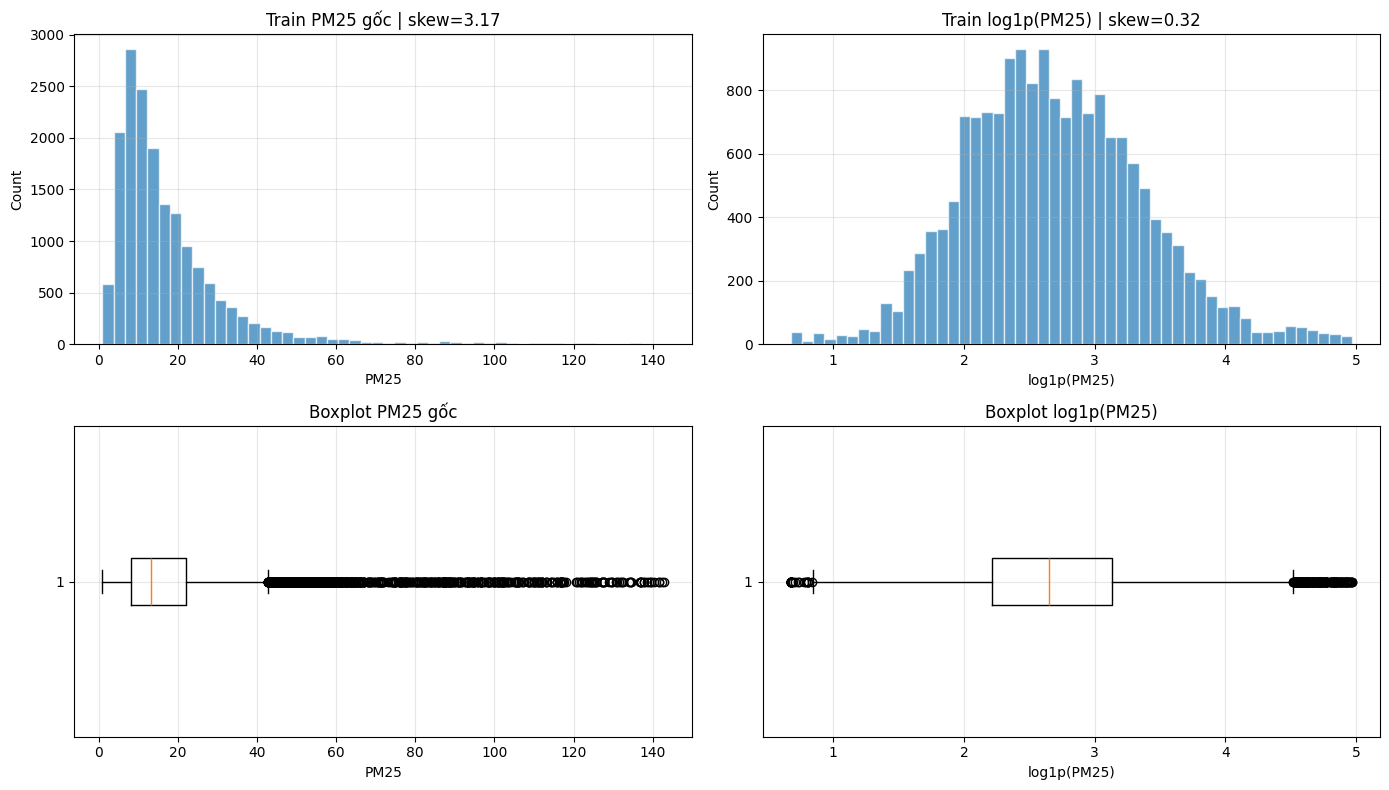

Skew raw : 3.1676353840749747
Skew log : 0.31574485817816217


In [16]:

y_train_raw_1d = y_train_raw.ravel()
y_val_raw_1d   = y_val_raw.ravel()
y_test_raw_1d  = y_test_raw.ravel()

y_train_t_1d = y_train_t.ravel()
y_val_t_1d   = y_val_t.ravel()
y_test_t_1d  = y_test_t.ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Histogram trước log
axes[0, 0].hist(y_train_raw_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 0].set_title(f"Train PM25 gốc | skew={pd.Series(y_train_raw_1d).skew():.2f}")
axes[0, 0].set_xlabel("PM25")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha=0.3)

# 2) Histogram sau log1p
axes[0, 1].hist(y_train_t_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 1].set_title(f"Train log1p(PM25) | skew={pd.Series(y_train_t_1d).skew():.2f}")
axes[0, 1].set_xlabel("log1p(PM25)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3)

# 3) Boxplot trước log
axes[1, 0].boxplot(y_train_raw_1d, vert=False)
axes[1, 0].set_title("Boxplot PM25 gốc")
axes[1, 0].set_xlabel("PM25")
axes[1, 0].grid(alpha=0.3)

# 4) Boxplot sau log1p
axes[1, 1].boxplot(y_train_t_1d, vert=False)
axes[1, 1].set_title("Boxplot log1p(PM25)")
axes[1, 1].set_xlabel("log1p(PM25)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Skew raw :", pd.Series(y_train_raw_1d).skew())
print("Skew log :", pd.Series(y_train_t_1d).skew())

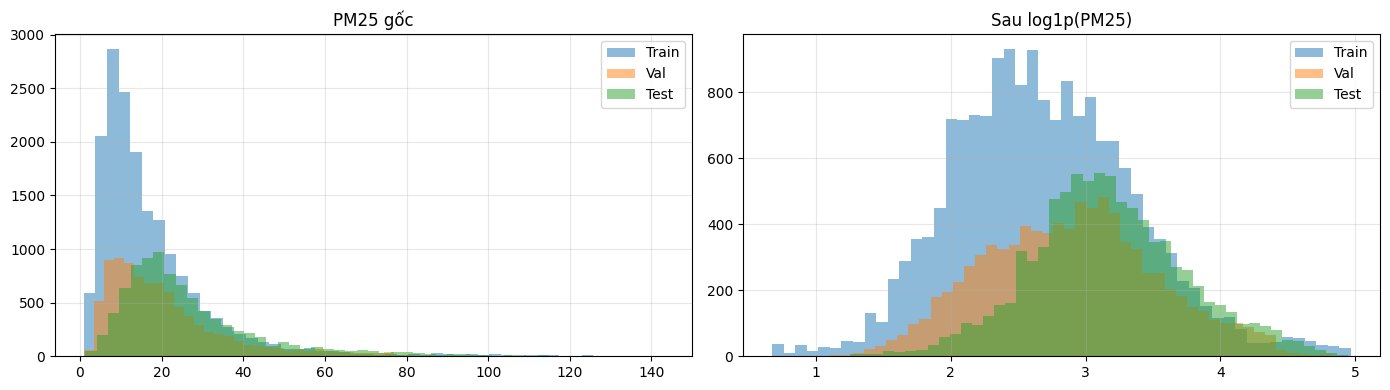

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train_raw.ravel(), bins=50, alpha=0.5, label="Train")
axes[0].hist(y_val_raw.ravel(), bins=50, alpha=0.5, label="Val")
axes[0].hist(y_test_raw.ravel(), bins=50, alpha=0.5, label="Test")
axes[0].set_title("PM25 gốc")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(y_train_t.ravel(), bins=50, alpha=0.5, label="Train")
axes[1].hist(y_val_t.ravel(), bins=50, alpha=0.5, label="Val")
axes[1].hist(y_test_t.ravel(), bins=50, alpha=0.5, label="Test")
axes[1].set_title("Sau log1p(PM25)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

(17201, 25) (8784, 25) (8750, 25)


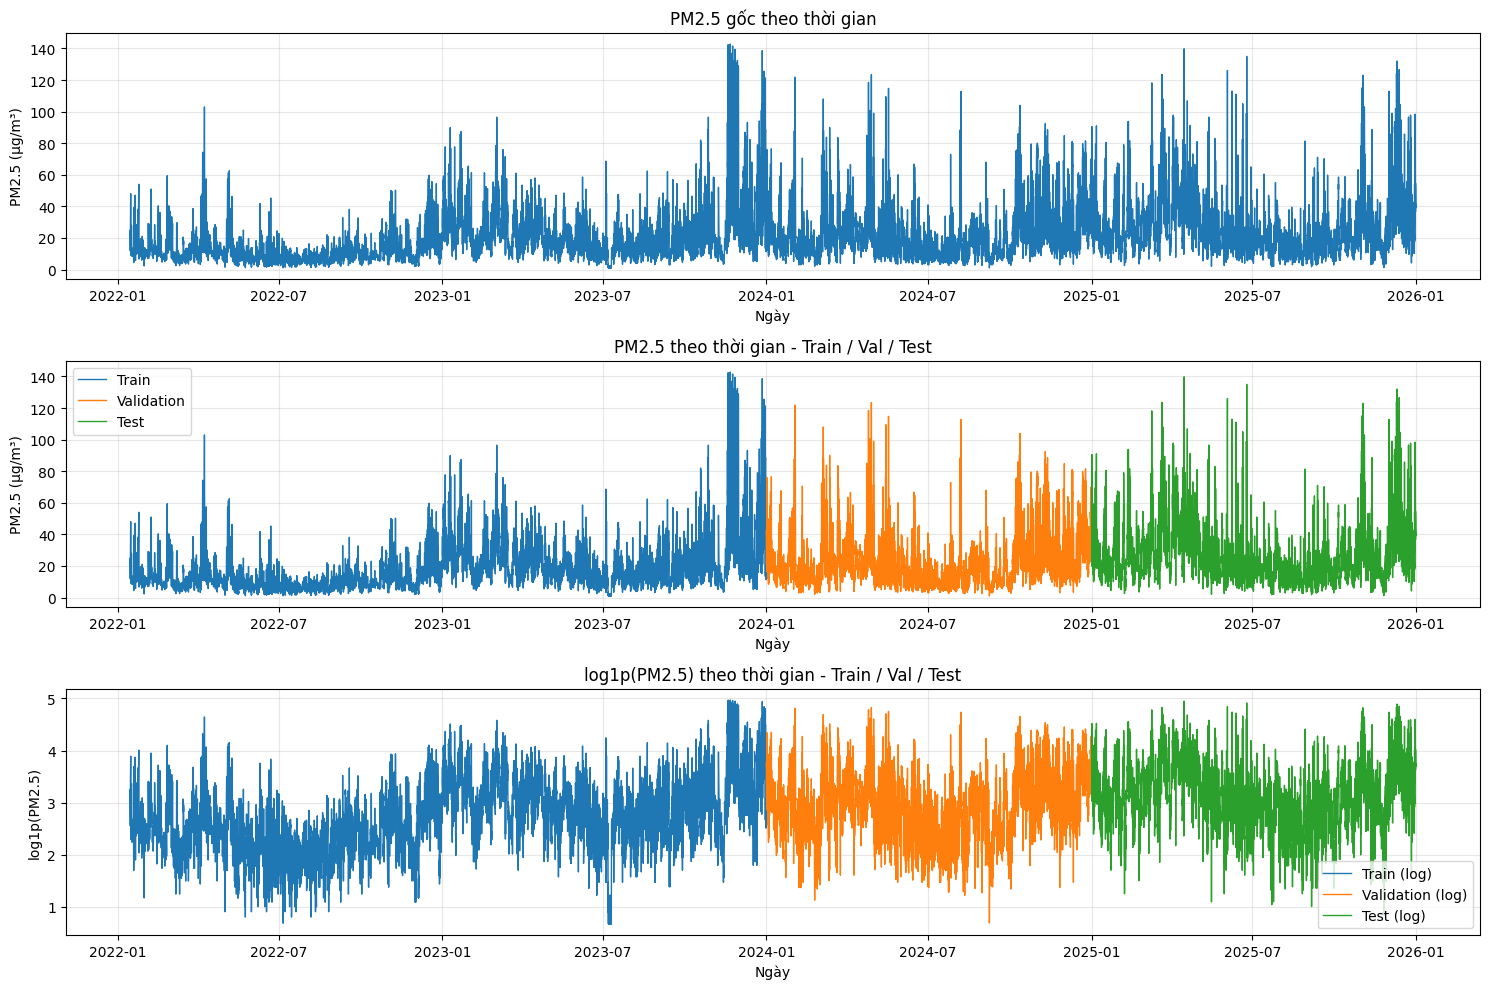

In [14]:
# đảm bảo index là datetime
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# ===== Split theo thời gian =====
train_end = "2023-12-31"
val_start = "2024-01-01"
val_end = "2024-12-31"
test_start = "2025-01-01"

train_df = df[:train_end].copy()
val_df   = df[val_start:val_end].copy()
test_df  = df[test_start:].copy()

print(train_df.shape, val_df.shape, test_df.shape)

# ===== Tạo log PM25 =====
train_log = np.log1p(train_df["PM25"])
val_log   = np.log1p(val_df["PM25"])
test_log  = np.log1p(test_df["PM25"])

# ===== Vẽ =====
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# 1) PM2.5 gốc toàn bộ theo thời gian
axes[0].plot(df.index, df["PM25"], linewidth=1)
axes[0].set_title("PM2.5 gốc theo thời gian")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_xlabel("Ngày")
axes[0].grid(True, alpha=0.3)

# 2) PM2.5 gốc theo split Train / Val / Test
axes[1].plot(train_df.index, train_df["PM25"], label="Train", linewidth=1)
axes[1].plot(val_df.index, val_df["PM25"], label="Validation", linewidth=1)
axes[1].plot(test_df.index, test_df["PM25"], label="Test", linewidth=1)
axes[1].set_title("PM2.5 theo thời gian - Train / Val / Test")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xlabel("Ngày")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3) log1p(PM2.5) theo split Train / Val / Test
axes[2].plot(train_df.index, train_log, label="Train (log)", linewidth=1)
axes[2].plot(val_df.index, val_log, label="Validation (log)", linewidth=1)
axes[2].plot(test_df.index, test_log, label="Test (log)", linewidth=1)
axes[2].set_title("log1p(PM2.5) theo thời gian - Train / Val / Test")
axes[2].set_ylabel("log1p(PM2.5)")
axes[2].set_xlabel("Ngày")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# 1) Spearman với target trên train thôi
spearman_pm25 = df.corr(method="spearman")["PM25"].drop("PM25")
print(spearman_pm25)

CO                           0.096524
NO2                          0.069152
O3                          -0.054366
PM10                         0.587030
SO2                          0.098712
Clouds                       0.005288
Precipitation               -0.163838
Pressure                     0.309512
Relative Humidity           -0.030139
Temperature                 -0.252552
UV Index                    -0.055504
Wind Speed                  -0.214932
IsHoliday                    0.036648
Accumulated Hours of Rain   -0.166417
hour                         0.007833
dayofweek                   -0.010823
month                       -0.012089
PM25_lag_1                   0.909151
PM25_lag_3                   0.823919
PM25_lag_24                  0.663977
PM25_roll_mean_3             0.895622
PM25_roll_mean_6             0.860541
PM25_roll_mean_24            0.792020
PM25_roll_std_24             0.626498
Name: PM25, dtype: float64


In [23]:
# Chuan bi feature cho GRU theo nhom bien co san tai thoi diem du bao.
# Khong loai feature bang corr thu cong; viec giu/bo se dua tren val metric.
df = df.copy()

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

base_features = [
    "PM25_lag_1", "PM25_lag_3", "PM25_lag_24",
    "PM25_roll_mean_24", "PM25_roll_std_24",
]

weather_features = [
    "Temperature", "Pressure", "Wind Speed",
    "Clouds", "Precipitation", "Relative Humidity",
    "Accumulated Hours of Rain",
]

pollution_features = ["PM10", "CO", "NO2", "O3", "SO2"]

calendar_features = [
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "IsHoliday",
]

feature_groups = {
    "base": base_features,
    "weather": weather_features,
    "pollution": pollution_features,
    "calendar": calendar_features,
}

candidate_feature_sets = {
    "base": base_features,
    "base_weather": base_features + weather_features,
    "base_weather_pollution": base_features + weather_features + pollution_features,
    "all": base_features + weather_features + pollution_features + calendar_features,
}

for name, cols in candidate_feature_sets.items():
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        print(f"{name}: missing -> {missing_cols}")
    else:
        print(f"{name}: {len(cols)} features")

feature_cols = candidate_feature_sets["all"]
print("Default feature_cols:", feature_cols)


base: 5 features
base_weather: 12 features
base_weather_pollution: 17 features
all: 24 features
Default feature_cols: ['PM25_lag_1', 'PM25_lag_3', 'PM25_lag_24', 'PM25_roll_mean_24', 'PM25_roll_std_24', 'Temperature', 'Pressure', 'Wind Speed', 'Clouds', 'Precipitation', 'Relative Humidity', 'Accumulated Hours of Rain', 'PM10', 'CO', 'NO2', 'O3', 'SO2', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'IsHoliday']


In [ ]:
candidate_data = {}

for name, cols in candidate_feature_sets.items():
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        print(f"{name}: missing -> {missing_cols}")
        continue

    candidate_data[name] = {
        "feature_cols": cols,
        "train_X": train_df[cols].copy(),
        "val_X": val_df[cols].copy(),
        "test_X": test_df[cols].copy(),
        "train_y": train_df[["PM25"]].copy(),
        "val_y": val_df[["PM25"]].copy(),
        "test_y": test_df[["PM25"]].copy(),
    }

for name, data in candidate_data.items():
    print(name, data["train_X"].shape, data["val_X"].shape, data["test_X"].shape)

ablation_order = list(candidate_data.keys())
print("Ablation order:", ablation_order)
print("Train GRU lan luot theo thu tu nay va so sanh val MAE / RMSE / MAPE.")


base (17201, 5) (8784, 5) (8750, 5)
base_weather (17201, 12) (8784, 12) (8750, 12)
base_weather_pollution (17201, 17) (8784, 17) (8750, 17)
all (17201, 24) (8784, 24) (8750, 24)
Ablation order: ['base', 'base_weather', 'base_weather_pollution', 'all']
Train GRU lan luot theo thu tu nay va so sanh val MAE / RMSE / MAPE.


In [ ]:
def 

In [ ]:
def build_gru_model(
    lookback: int,
    n_features: int,
    horizon: int,
    gru_units: int = 96,
    dense_units: int = 64,
    dropout: float = 0.2,
    learning_rate: float = 1e-3,
) -> tf.keras.Model:
    model = tf.keras.Sequential(
        [
            tf.keras.layers.GRU(
                gru_units,
                return_sequences=False,
                input_shape=(lookback, n_features),
            ),
            tf.keras.layers.Dropout(dropout),
            tf.keras.layers.Dense(dense_units, activation="relu"),
            tf.keras.layers.Dropout(dropout),
            tf.keras.layers.Dense(horizon),
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

In [ ]:







def _metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=np.float64).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=np.float64).reshape(-1)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": float(mean_absolute_percentage_error(y_true, y_pred) * 100.0),
    }


def train_single_fold(
    fold_artifacts: dict[str, Any],
    seed: int = 42,
    epochs: int = 40,
    batch_size: int = 64,
    verbose: int = 0,
) -> dict[str, Any]:
    set_seed(seed)

    cfg: DataConfig = fold_artifacts["cfg"]
    n_features = int(fold_artifacts["n_features"])

    model = build_gru_model(
        lookback=cfg.lookback,
        n_features=n_features,
        horizon=cfg.horizon,
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
            min_delta=1e-4,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=0,
        ),
    ]

    history = model.fit(
        fold_artifacts["X_train_seq"],
        fold_artifacts["y_train_seq"],
        validation_data=(fold_artifacts["X_val_seq"], fold_artifacts["y_val_seq"]),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
    )

    y_val_pred_scaled = model.predict(fold_artifacts["X_val_seq"], verbose=0)
    y_val_true = inverse_y(
        fold_artifacts["y_val_seq"],
        fold_artifacts["target_transformer"],
    )
    y_val_pred = inverse_y(
        y_val_pred_scaled,
        fold_artifacts["target_transformer"],
    )

    val_metrics = _metrics(y_val_true, y_val_pred)

    result = {
        "model": model,
        "history": history.history,
        "fold": fold_artifacts.get("fold"),
        "walk_forward": fold_artifacts.get("walk_forward"),
        "val_metrics": val_metrics,
        "y_val_true": y_val_true,
        "y_val_pred": y_val_pred,
        "val_times": fold_artifacts.get("val_times"),
    }
    return result


def run_walk_forward_training(
    cfg: DataConfig,
    eval_size: int = 72,
    step_size: int = 24,
    max_folds: int = 4,
    expanding: bool = True,
    train_size: int | None = None,
    seed: int = 42,
    epochs: int = 40,
    batch_size: int = 64,
    verbose: int = 0,
) -> dict[str, Any]:
    folds = prepare_walk_forward_datasets(
        cfg,
        eval_size=eval_size,
        step_size=step_size,
        max_folds=max_folds,
        expanding=expanding,
        train_size=train_size,
    )

    fold_results: list[dict[str, Any]] = []
    rows: list[dict[str, Any]] = []

    for fold_artifacts in folds:
        fold_res = train_single_fold(
            fold_artifacts=fold_artifacts,
            seed=seed,
            epochs=epochs,
            batch_size=batch_size,
            verbose=verbose,
        )
        fold_results.append(fold_res)

        info = fold_artifacts.get("walk_forward", {})
        rows.append(
            {
                "fold": int(info.get("fold", len(rows) + 1)),
                "train_end": info.get("train_end"),
                "val_start": info.get("val_start"),
                "val_end": info.get("val_end"),
                "val_mae": fold_res["val_metrics"]["mae"],
                "val_rmse": fold_res["val_metrics"]["rmse"],
                "val_mape": fold_res["val_metrics"]["mape"],
            }
        )

    fold_metrics_df = pd.DataFrame(rows)
    summary = {
        "mae_mean": float(fold_metrics_df["val_mae"].mean()),
        "mae_std": float(fold_metrics_df["val_mae"].std(ddof=0)),
        "rmse_mean": float(fold_metrics_df["val_rmse"].mean()),
        "rmse_std": float(fold_metrics_df["val_rmse"].std(ddof=0)),
        "mape_mean": float(fold_metrics_df["val_mape"].mean()),
        "mape_std": float(fold_metrics_df["val_mape"].std(ddof=0)),
    }

    return {
        "cfg": asdict(cfg),
        "fold_metrics": fold_metrics_df,
        "summary": summary,
        "fold_results": fold_results,
    }


def train_final_model(
    cfg: DataConfig,
    seed: int = 42,
    epochs: int = 40,
    batch_size: int = 64,
    verbose: int = 0,
) -> dict[str, Any]:
    artifacts = prepare_dataset(cfg)

    result = train_single_fold(
        fold_artifacts=artifacts,
        seed=seed,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
    )

    return {
        "artifacts": artifacts,
        "model": result["model"],
        "history": result["history"],
        "val_metrics": result["val_metrics"],
    }


def forecast_next_hours(
    model: tf.keras.Model,
    artifacts: dict[str, Any],
    hours: int = 72,
) -> pd.DataFrame:
    cfg: DataConfig = artifacts["cfg"]

    if hours <= 0:
        raise ValueError("hours phải > 0.")

    if hours > cfg.horizon:
        raise ValueError(
            f"Model đang output horizon={cfg.horizon}. Hãy forecast <= {cfg.horizon} giờ."
        )

    df_all = artifacts["df"].sort_index()
    preprocessor = artifacts["preprocessor"]
    target_transformer = artifacts["target_transformer"]

    X_all = preprocessor.transform(df_all, target=cfg.target)
    if len(X_all) < cfg.lookback:
        raise ValueError("Không đủ dữ liệu để tạo cửa sổ lookback cho dự báo.")

    last_window = X_all[-cfg.lookback :]
    y_pred_scaled = model.predict(last_window[np.newaxis, ...], verbose=0)[0]
    y_pred = target_transformer.inverse_transform(y_pred_scaled[:hours]).reshape(-1)
    y_pred = np.clip(y_pred, 0.0, None)

    start_time = df_all.index.max() + pd.tseries.frequencies.to_offset(cfg.freq)
    future_index = pd.date_range(start=start_time, periods=hours, freq=cfg.freq)

    return pd.DataFrame(
        {
            "timestamp": future_index,
            "pm25_pred": y_pred,
        }
    )


def summarize_daily_forecast(hourly_forecast: pd.DataFrame) -> pd.DataFrame:
    daily = (
        hourly_forecast.assign(date=hourly_forecast["timestamp"].dt.date)
        .groupby("date", as_index=False)
        .agg(
            pm25_mean=("pm25_pred", "mean"),
            pm25_max=("pm25_pred", "max"),
            pm25_min=("pm25_pred", "min"),
        )
    )
    return daily


def run_cli() -> None:
    parser = argparse.ArgumentParser(description="Train GRU with walk-forward and forecast next 72 hours.")
    parser.add_argument("--eval-size", type=int, default=72)
    parser.add_argument("--step-size", type=int, default=24)
    parser.add_argument("--max-folds", type=int, default=4)
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--batch-size", type=int, default=64)
    parser.add_argument("--expanding", action="store_true", default=True)
    parser.add_argument("--output-dir", type=str, default="data/processed")
    args = parser.parse_args()

    cfg = DataConfig()

    walk_result = run_walk_forward_training(
        cfg=cfg,
        eval_size=args.eval_size,
        step_size=args.step_size,
        max_folds=args.max_folds,
        expanding=args.expanding,
        epochs=args.epochs,
        batch_size=args.batch_size,
        verbose=0,
    )

    print("Walk-forward fold metrics:")
    print(walk_result["fold_metrics"].to_string(index=False))
    print("\nWalk-forward summary:")
    for k, v in walk_result["summary"].items():
        print(f"  {k}: {v:.4f}")

    final_fit = train_final_model(
        cfg=cfg,
        epochs=args.epochs,
        batch_size=args.batch_size,
        verbose=0,
    )
    hourly = forecast_next_hours(final_fit["model"], final_fit["artifacts"], hours=72)
    daily = summarize_daily_forecast(hourly)

    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    hourly_path = output_dir / "gru_forecast_72h.csv"
    daily_path = output_dir / "gru_forecast_daily.csv"

    hourly.to_csv(hourly_path, index=False)
    daily.to_csv(daily_path, index=False)

    print(f"\nSaved hourly forecast: {hourly_path}")
    print(f"Saved daily forecast: {daily_path}")


if __name__ == "__main__":
    run_cli()





def _metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=np.float64).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=np.float64).reshape(-1)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": float(mean_absolute_percentage_error(y_true, y_pred) * 100.0),
    }


def train_single_fold(
    fold_artifacts: dict[str, Any],
    seed: int = 42,
    epochs: int = 40,
    batch_size: int = 64,
    verbose: int = 0,
) -> dict[str, Any]:
    set_seed(seed)

    cfg: DataConfig = fold_artifacts["cfg"]
    n_features = int(fold_artifacts["n_features"])

    model = build_gru_model(
        lookback=cfg.lookback,
        n_features=n_features,
        horizon=cfg.horizon,
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
            min_delta=1e-4,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=0,
        ),
    ]

    history = model.fit(
        fold_artifacts["X_train_seq"],
        fold_artifacts["y_train_seq"],
        validation_data=(fold_artifacts["X_val_seq"], fold_artifacts["y_val_seq"]),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
    )

    y_val_pred_scaled = model.predict(fold_artifacts["X_val_seq"], verbose=0)
    y_val_true = inverse_y(
        fold_artifacts["y_val_seq"],
        fold_artifacts["target_transformer"],
    )
    y_val_pred = inverse_y(
        y_val_pred_scaled,
        fold_artifacts["target_transformer"],
    )

    val_metrics = _metrics(y_val_true, y_val_pred)

    result = {
        "model": model,
        "history": history.history,
        "fold": fold_artifacts.get("fold"),
        "walk_forward": fold_artifacts.get("walk_forward"),
        "val_metrics": val_metrics,
        "y_val_true": y_val_true,
        "y_val_pred": y_val_pred,
        "val_times": fold_artifacts.get("val_times"),
    }
    return result


def run_walk_forward_training(
    cfg: DataConfig,
    eval_size: int = 72,
    step_size: int = 24,
    max_folds: int = 4,
    expanding: bool = True,
    train_size: int | None = None,
    seed: int = 42,
    epochs: int = 40,
    batch_size: int = 64,
    verbose: int = 0,
) -> dict[str, Any]:
    folds = prepare_walk_forward_datasets(
        cfg,
        eval_size=eval_size,
        step_size=step_size,
        max_folds=max_folds,
        expanding=expanding,
        train_size=train_size,
    )

    fold_results: list[dict[str, Any]] = []
    rows: list[dict[str, Any]] = []

    for fold_artifacts in folds:
        fold_res = train_single_fold(
            fold_artifacts=fold_artifacts,
            seed=seed,
            epochs=epochs,
            batch_size=batch_size,
            verbose=verbose,
        )
        fold_results.append(fold_res)

        info = fold_artifacts.get("walk_forward", {})
        rows.append(
            {
                "fold": int(info.get("fold", len(rows) + 1)),
                "train_end": info.get("train_end"),
                "val_start": info.get("val_start"),
                "val_end": info.get("val_end"),
                "val_mae": fold_res["val_metrics"]["mae"],
                "val_rmse": fold_res["val_metrics"]["rmse"],
                "val_mape": fold_res["val_metrics"]["mape"],
            }
        )

    fold_metrics_df = pd.DataFrame(rows)
    summary = {
        "mae_mean": float(fold_metrics_df["val_mae"].mean()),
        "mae_std": float(fold_metrics_df["val_mae"].std(ddof=0)),
        "rmse_mean": float(fold_metrics_df["val_rmse"].mean()),
        "rmse_std": float(fold_metrics_df["val_rmse"].std(ddof=0)),
        "mape_mean": float(fold_metrics_df["val_mape"].mean()),
        "mape_std": float(fold_metrics_df["val_mape"].std(ddof=0)),
    }

    return {
        "cfg": asdict(cfg),
        "fold_metrics": fold_metrics_df,
        "summary": summary,
        "fold_results": fold_results,
    }


def train_final_model(
    cfg: DataConfig,
    seed: int = 42,
    epochs: int = 40,
    batch_size: int = 64,
    verbose: int = 0,
) -> dict[str, Any]:
    artifacts = prepare_dataset(cfg)

    result = train_single_fold(
        fold_artifacts=artifacts,
        seed=seed,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
    )

    return {
        "artifacts": artifacts,
        "model": result["model"],
        "history": result["history"],
        "val_metrics": result["val_metrics"],
    }


def forecast_next_hours(
    model: tf.keras.Model,
    artifacts: dict[str, Any],
    hours: int = 72,
) -> pd.DataFrame:
    cfg: DataConfig = artifacts["cfg"]

    if hours <= 0:
        raise ValueError("hours phải > 0.")

    if hours > cfg.horizon:
        raise ValueError(
            f"Model đang output horizon={cfg.horizon}. Hãy forecast <= {cfg.horizon} giờ."
        )

    df_all = artifacts["df"].sort_index()
    preprocessor = artifacts["preprocessor"]
    target_transformer = artifacts["target_transformer"]

    X_all = preprocessor.transform(df_all, target=cfg.target)
    if len(X_all) < cfg.lookback:
        raise ValueError("Không đủ dữ liệu để tạo cửa sổ lookback cho dự báo.")

    last_window = X_all[-cfg.lookback :]
    y_pred_scaled = model.predict(last_window[np.newaxis, ...], verbose=0)[0]
    y_pred = target_transformer.inverse_transform(y_pred_scaled[:hours]).reshape(-1)
    y_pred = np.clip(y_pred, 0.0, None)

    start_time = df_all.index.max() + pd.tseries.frequencies.to_offset(cfg.freq)
    future_index = pd.date_range(start=start_time, periods=hours, freq=cfg.freq)

    return pd.DataFrame(
        {
            "timestamp": future_index,
            "pm25_pred": y_pred,
        }
    )


def summarize_daily_forecast(hourly_forecast: pd.DataFrame) -> pd.DataFrame:
    daily = (
        hourly_forecast.assign(date=hourly_forecast["timestamp"].dt.date)
        .groupby("date", as_index=False)
        .agg(
            pm25_mean=("pm25_pred", "mean"),
            pm25_max=("pm25_pred", "max"),
            pm25_min=("pm25_pred", "min"),
        )
    )
    return daily


def run_cli() -> None:
    parser = argparse.ArgumentParser(description="Train GRU with walk-forward and forecast next 72 hours.")
    parser.add_argument("--eval-size", type=int, default=72)
    parser.add_argument("--step-size", type=int, default=24)
    parser.add_argument("--max-folds", type=int, default=4)
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--batch-size", type=int, default=64)
    parser.add_argument("--expanding", action="store_true", default=True)
    parser.add_argument("--output-dir", type=str, default="data/processed")
    args = parser.parse_args()

    cfg = DataConfig()

    walk_result = run_walk_forward_training(
        cfg=cfg,
        eval_size=args.eval_size,
        step_size=args.step_size,
        max_folds=args.max_folds,
        expanding=args.expanding,
        epochs=args.epochs,
        batch_size=args.batch_size,
        verbose=0,
    )

    print("Walk-forward fold metrics:")
    print(walk_result["fold_metrics"].to_string(index=False))
    print("\nWalk-forward summary:")
    for k, v in walk_result["summary"].items():
        print(f"  {k}: {v:.4f}")

    final_fit = train_final_model(
        cfg=cfg,
        epochs=args.epochs,
        batch_size=args.batch_size,
        verbose=0,
    )
    hourly = forecast_next_hours(final_fit["model"], final_fit["artifacts"], hours=72)
    daily = summarize_daily_forecast(hourly)

    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    hourly_path = output_dir / "gru_forecast_72h.csv"
    daily_path = output_dir / "gru_forecast_daily.csv"

    hourly.to_csv(hourly_path, index=False)
    daily.to_csv(daily_path, index=False)

    print(f"\nSaved hourly forecast: {hourly_path}")
    print(f"Saved daily forecast: {daily_path}")


if __name__ == "__main__":
    run_cli()
